In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

In [4]:

# 2) Resnet-9 model 
def residual_block(in_channels, out_channels, pool=False):
    layers = [
        nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1),
        # nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(nn.Module):
    def __init__(self, model_args):
        super().__init__()
        """
        Initializes the ResNet-9 model.
        
        Args:
            in_channels (int): Number of input channels.
            num_classes (int): Number of classes in the dataset.
            input_size (tuple): Size of the input images.
        """
        
        in_channels = model_args["in_channels"]
        num_classes = model_args["num_classes"]
        input_size = model_args["input_size"]
        scaling = 2
        
        self.prep = residual_block(in_channels, 64//scaling)
        self.layer1_head = residual_block(64//scaling, 128//scaling, pool=True)
        self.layer1_residual = nn.Sequential(residual_block(128//scaling, 128//scaling), residual_block(128//scaling, 128//scaling))
        self.layer2 = residual_block(128//scaling, 256//scaling, pool=True)
        self.layer3_head = residual_block(256//scaling, 512//scaling, pool=True)
        self.layer3_residual = nn.Sequential(residual_block(512//scaling, 512//scaling), residual_block(512//scaling, 512//scaling))
        # self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # Changed to adaptive average pooling:         self.MaxPool2d = nn.Sequential(nn.MaxPool2d(4))
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Calculate the size of the features after the convolutional layers
        dummy_input = torch.zeros(1, in_channels, *input_size)
        dummy_output = self.pool(self.layer3_head(self.layer2(self.layer1_head(self.prep(dummy_input)))))
        self.feature_size = dummy_output.size(1) * dummy_output.size(2) * dummy_output.size(3)

        # Output layer
        self.linear = nn.Linear(self.feature_size, num_classes)

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1_head(x)
        x = self.layer1_residual(x) + x
        x = self.layer2(x)
        x = self.layer3_head(x)
        x = self.layer3_residual(x) + x
        x = self.pool(x)  # Changed to adaptive average pooling
        x_rec = x.view(x.size(0), -1)
        x = self.linear(x_rec)
        return x

# Load weights

config ={
            "in_channels": 3,
            "num_classes": 10,
            "input_size": (32, 32),
        }
model = ResNet9(config)
path = "/home/dario/Projects/Federated_Learning/eris/experiments_unbiased_pareto/fedavg/checkpoints/ResNet9/cifar10/model_220.pth"
model.load_state_dict(torch.load(path, weights_only=False))



<All keys matched successfully>

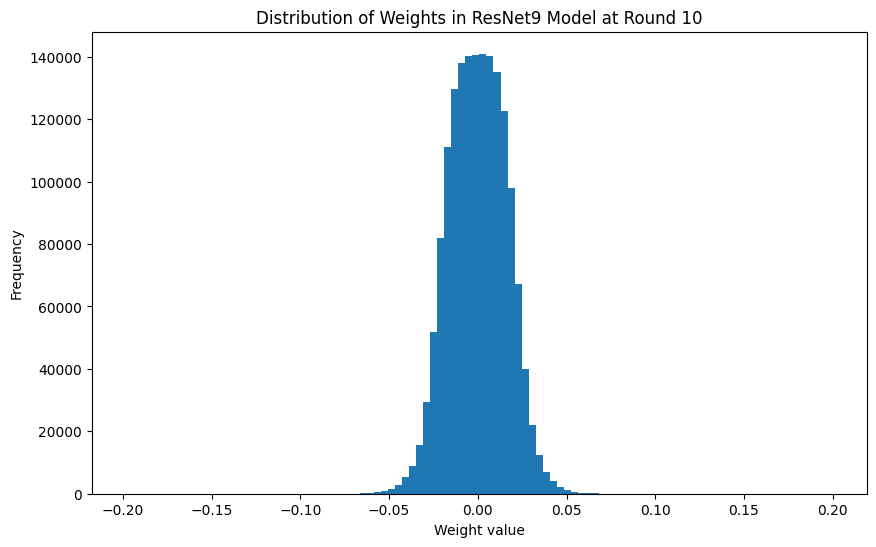

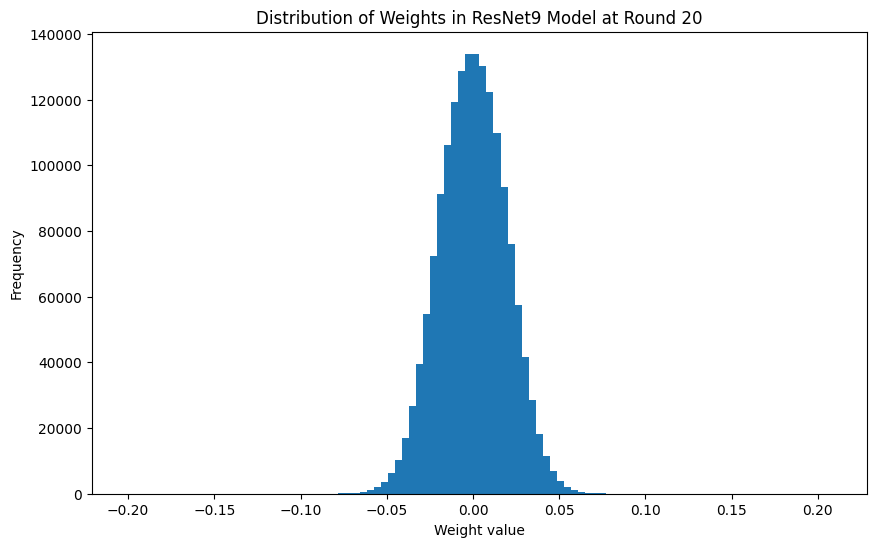

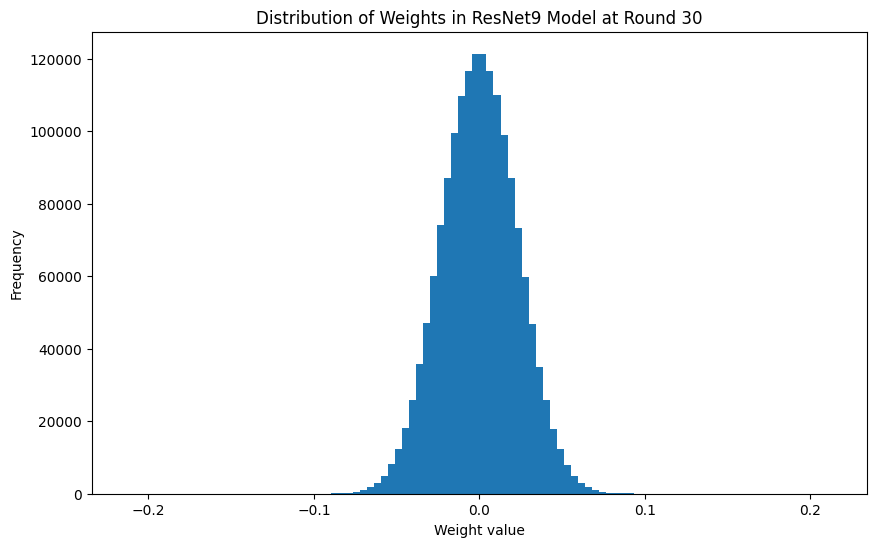

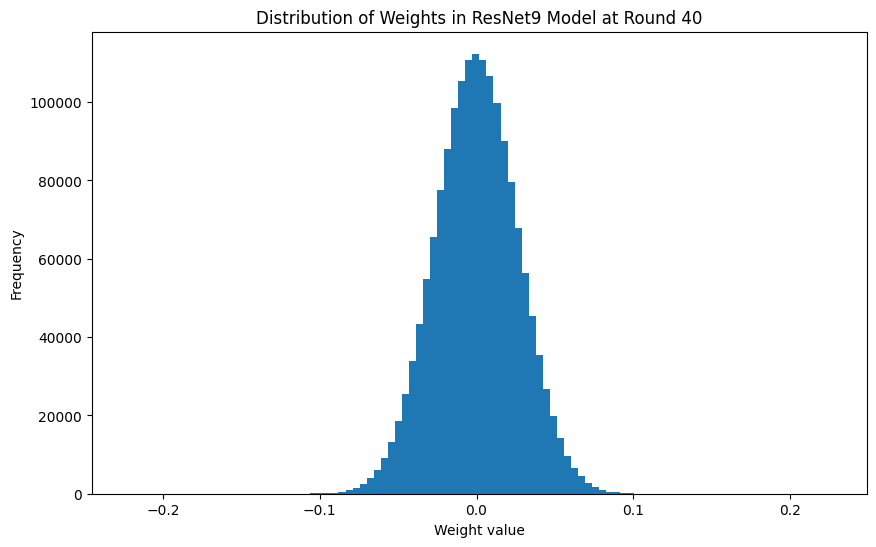

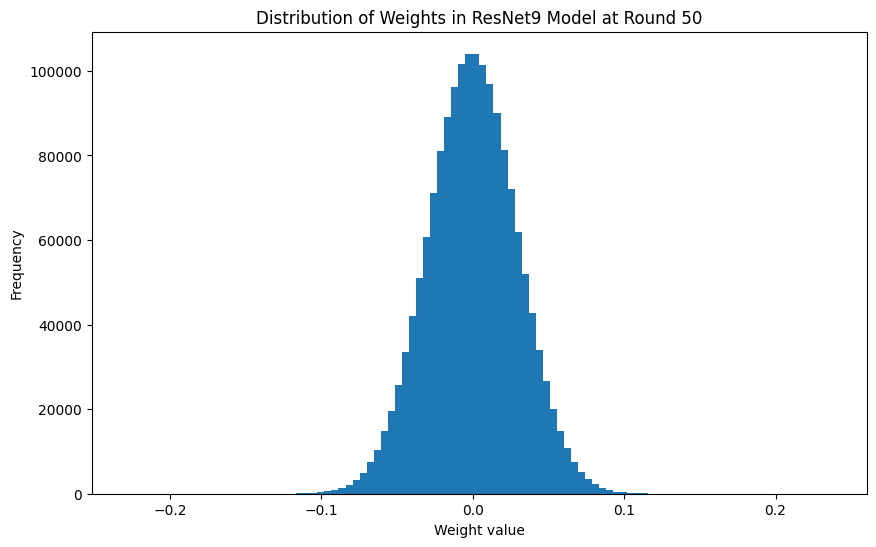

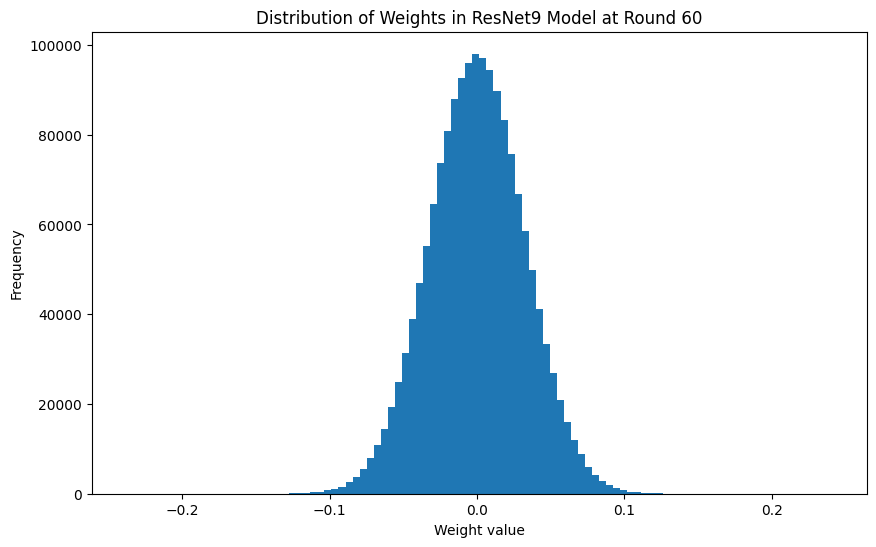

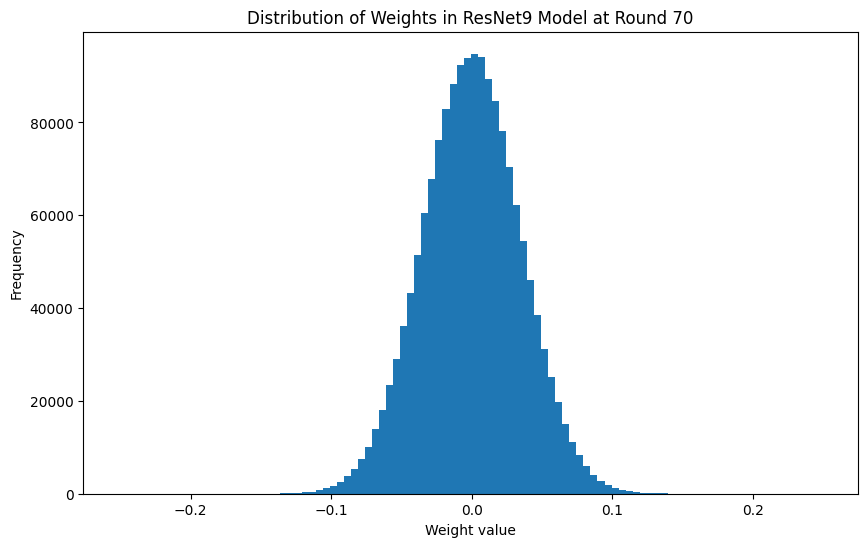

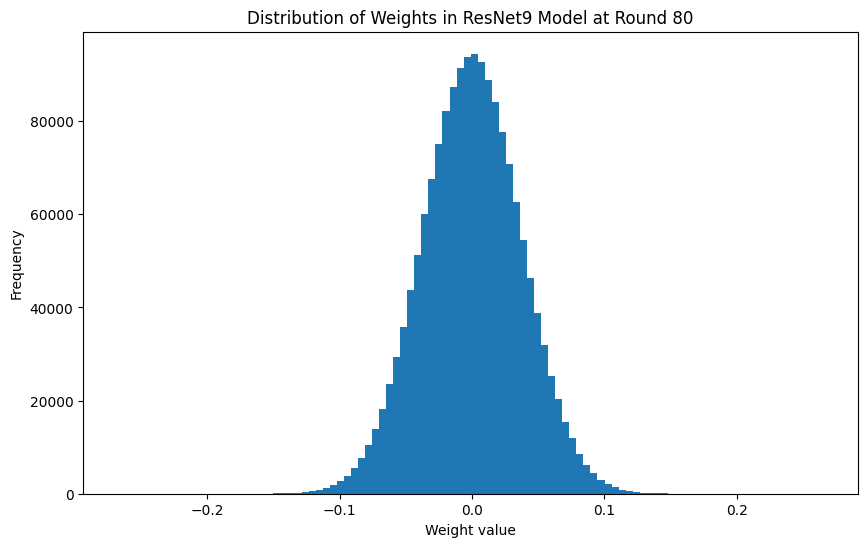

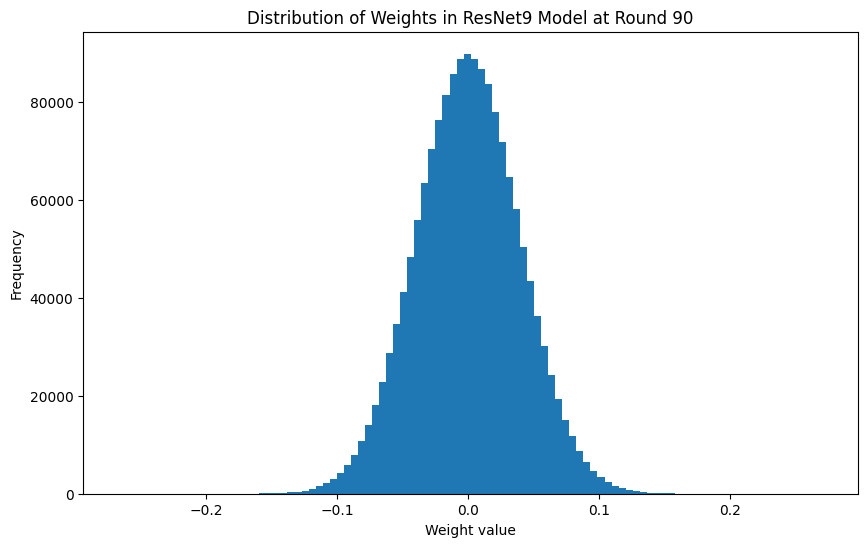

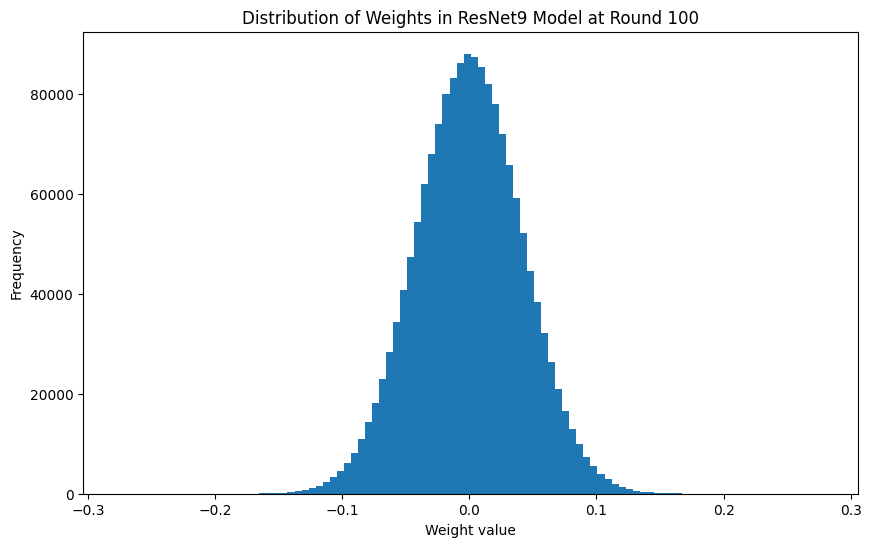

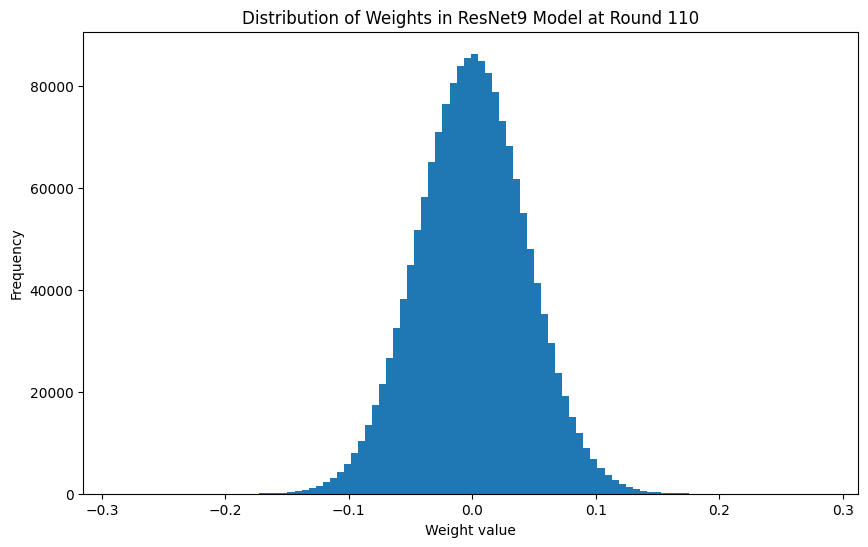

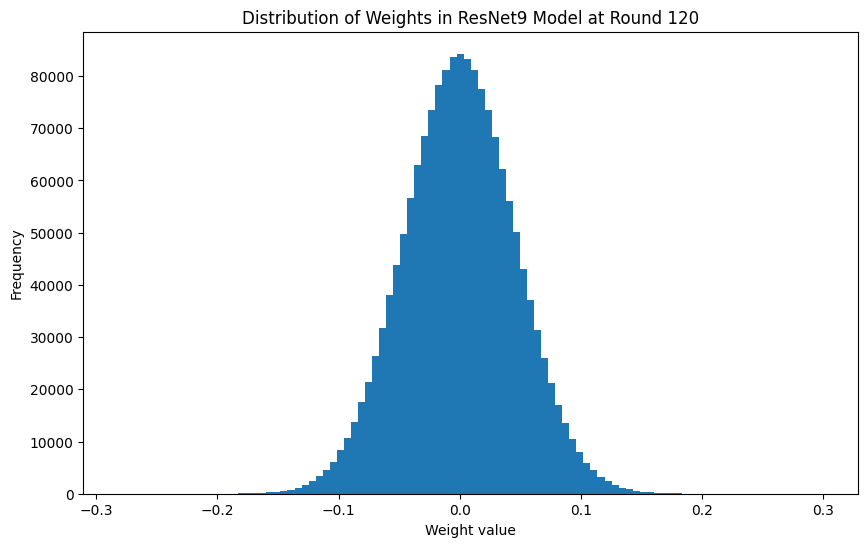

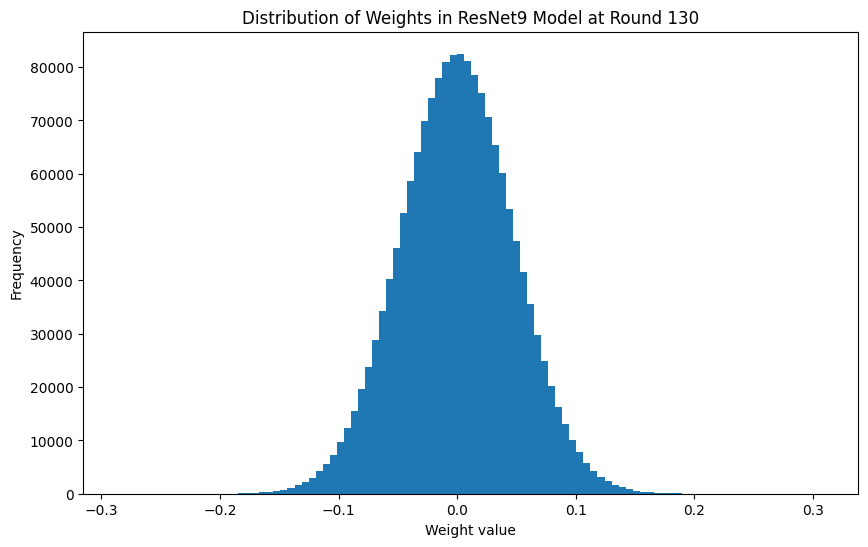

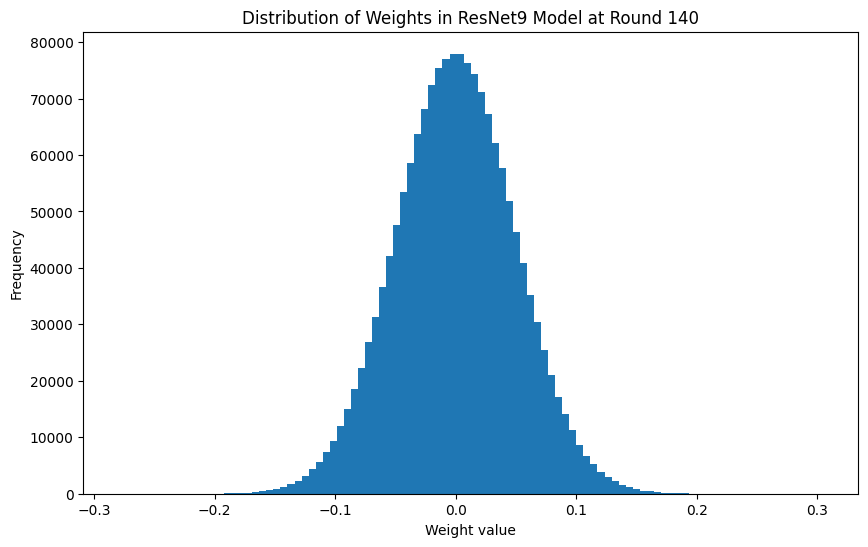

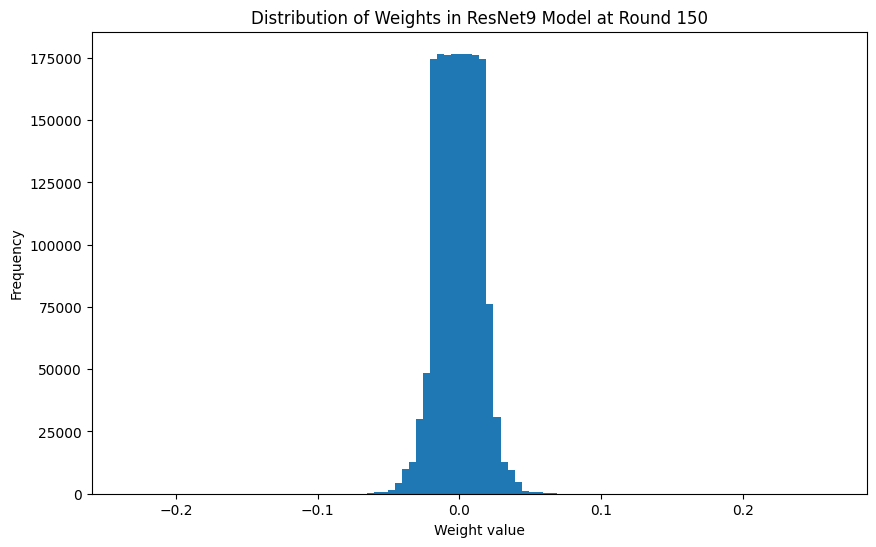

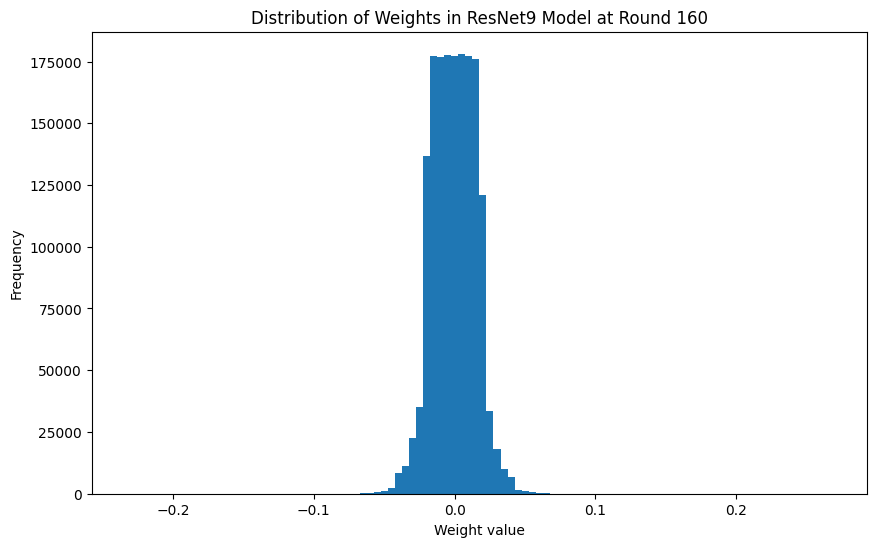

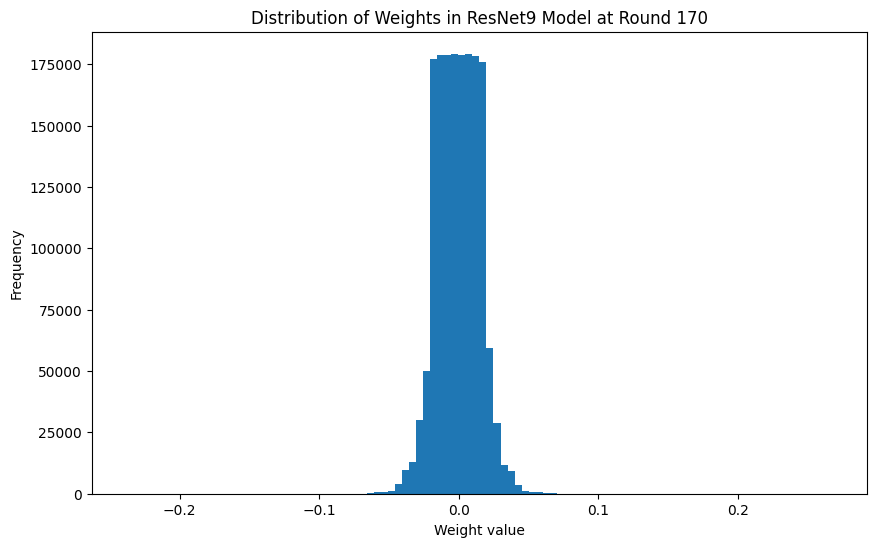

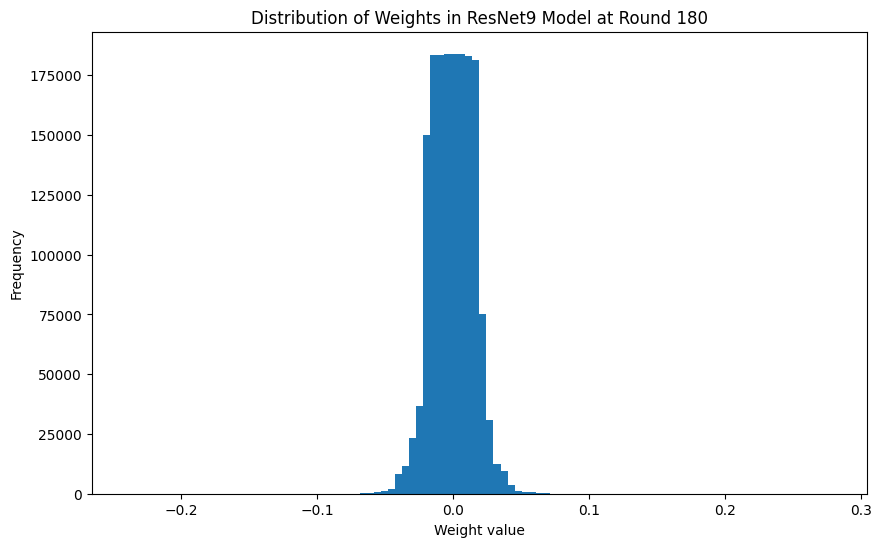

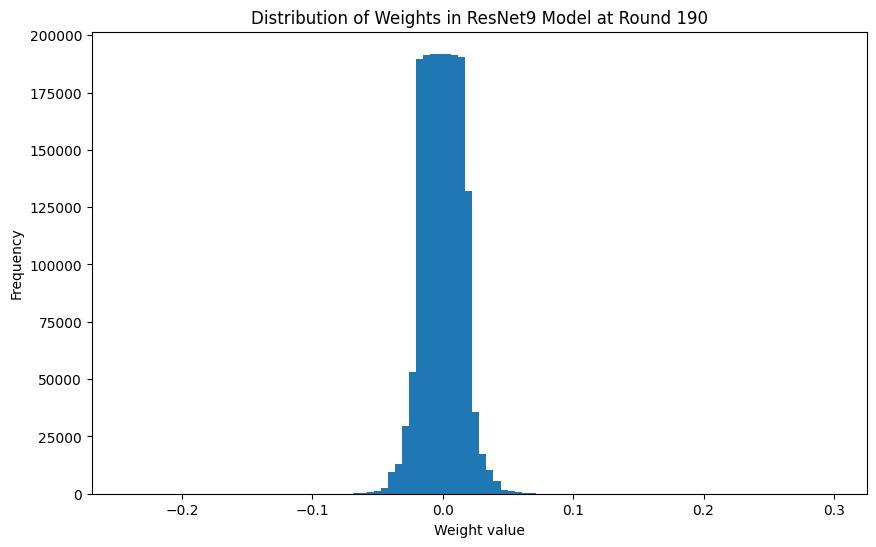

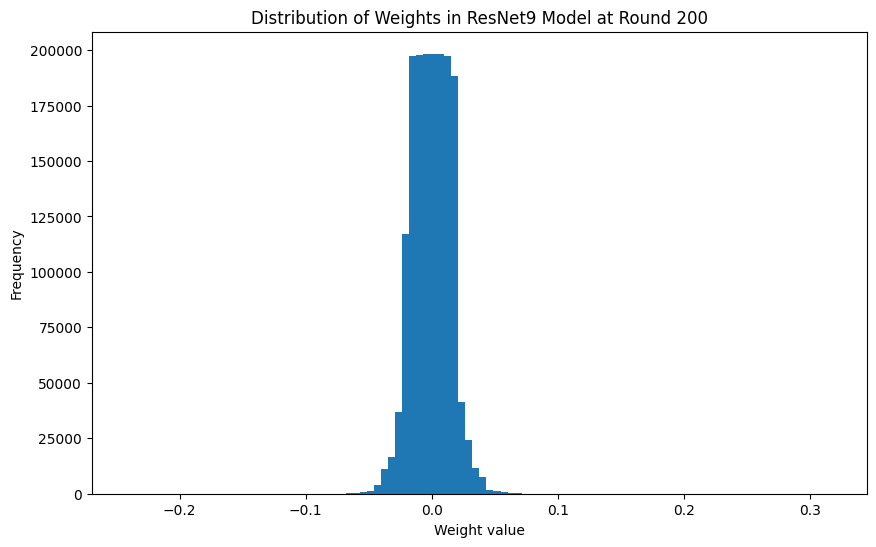

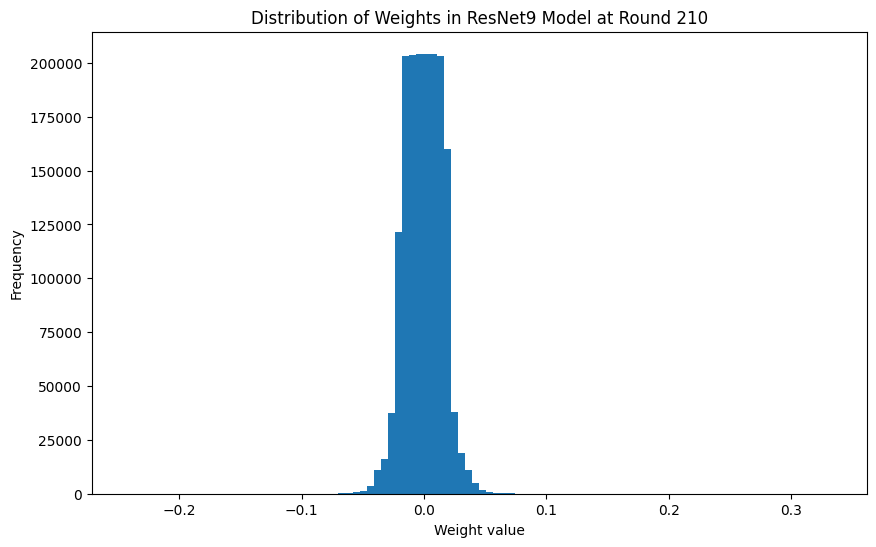

In [ ]:
import matplotlib.pyplot as plt
config ={
            "in_channels": 3,
            "num_classes": 10,
            "input_size": (32, 32),
        }
    
for i in range(20, 220, 20):

    model = ResNet9(config)
    path = f"/home/dario/Projects/Federated_Learning/eris/experiments_unbiased_pareto/fedavg/checkpoints/ResNet9/cifar10/model_{i}.pth"
    model.load_state_dict(torch.load(path, weights_only=False))

    # Flatten the parameters
    flat_params = []
    for param in model.parameters():
        flat_params.extend(param.data.cpu().numpy().ravel())

    # remove values our
    flat_params = np.array([x for x in flat_params if -1 <= x <= 1])

    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.hist(flat_params, bins=100)
    plt.xlabel("Weight value")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Weights in ResNet9 Model at Round {i}")
    plt.show()

In [ ]:
for i in range(10, 220, 10):
    config ={
                "in_channels": 3,
                "num_classes": 10,
                "input_size": (32, 32),
            }
    model = ResNet9(config)
    path = f"/home/dario/Projects/Federated_Learning/eris/experiments_unbiased_pareto/fedavg/checkpoints/ResNet9/cifar10/model_{i}.pth"
    model.load_state_dict(torch.load(path, weights_only=False))


    # Flatten the parameters
    flat_params = []
    for param in model.parameters():
        flat_params.extend(param.data.cpu().numpy().ravel())

In [ ]:
import os
from tqdm import tqdm
os.makedirs("./weight distributions/", exist_ok=True)
# Flatten the parameters

for i in tqdm(range(20, 220, 20)):
    config ={
                "in_channels": 3,
                "num_classes": 10,
                "input_size": (32, 32),
            }
    model = ResNet9(config)
    path = f"/home/dario/Projects/Federated_Learning/eris/experiments_unbiased_pareto/fedavg/checkpoints/ResNet9/cifar10/model_{i}.pth"
    model.load_state_dict(torch.load(path, weights_only=False))

    
    flat_params = []
    for param in model.parameters():
        flat_params.extend(param.data.cpu().numpy().ravel())
    
    # remove values our
    flat_params = np.array([x for x in flat_params if -1 <= x <= 1])

    # save the distribution
    np.save(f"./weight distributions/weights_{i}.npy", flat_params)

100%|██████████| 10/10 [00:52<00:00,  5.21s/it]


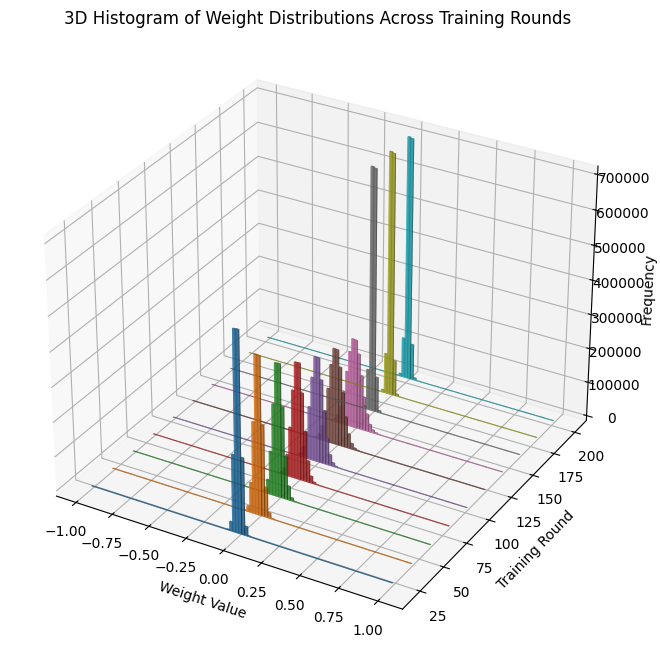

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

config = {
    "in_channels": 3,
    "num_classes": 10,
    "input_size": (32, 32),
}

rounds = list(range(20, 220, 20))
num_bins = 100
bin_range = (-1, 1)
all_hist = []

for r in rounds:
    # Load the precomputed weights
    flat_params = np.load(f"./weight distributions/weights_{r}.npy")
    
    hist, bin_edges = np.histogram(flat_params, bins=num_bins, range=bin_range)
    all_hist.append(hist)

all_hist = np.array(all_hist)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Define the bar dimensions
dx = (bin_edges[1] - bin_edges[0]) * np.ones_like(bin_centers)  # bin width for each bar
dy = 1.0  # a constant width for the training round dimension

# Loop over training rounds and plot the bars for each histogram bin.
for i, r in enumerate(rounds):
    xs = bin_centers  # x positions (bin centers)
    ys = np.full_like(bin_centers, r)  # y positions (training round r)
    zs = np.zeros_like(bin_centers)  # start at z=0
    dz = all_hist[i]  # height is given by the histogram frequency
    ax.bar3d(xs, ys, zs, dx, dy, dz, shade=True, alpha=0.6)

ax.set_xlabel("Weight Value")
ax.set_ylabel("Training Round")
ax.set_zlabel("Frequency")
ax.set_title("3D Histogram of Weight Distributions Across Training Rounds")
plt.show()

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from math import prod

class LeNet5(nn.Module):
    def __init__(self, model_args):
        """
        Initializes the LeNet-5 model.
        
        Args:
            in_channels (int): Number of input channels.
            num_classes (int): Number of classes in the dataset.
            input_size (tuple): Size of the input images.       
        """
        super(LeNet5, self).__init__()
        
        in_channels = model_args["in_channels"]
        num_classes = model_args["num_classes"]
        input_size = model_args["input_size"]
        
        self.conv1 = nn.Conv2d(in_channels, 6, kernel_size=5, stride=1, padding=2)  # Convolutional layer with 6 feature maps of size 5x5
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)  # Subsampling layer with 6 feature maps of size 2x2
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)  # Convolutional layer with 16 feature maps of size 5x5
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)  # Subsampling layer with 16 feature maps of size 2x2
        
        # Dinamically calculate the size of the features after convolutional layers
        dummy_input = torch.zeros(1, in_channels, *input_size)
        dummy_output = self.pool2(self.conv2(self.pool1(self.conv1(dummy_input))))
        self.feature_size = prod(dummy_output.size()[1:])

        self.fc1 = nn.Linear(self.feature_size, 120)  # Fully connected layer, output size 120
        self.fc2 = nn.Linear(120, 84)  # Fully connected layer, output size 84
        self.fc3 = nn.Linear(84, num_classes)  # Fully connected layer, output size num_classes

    def forward(self, x):
        x = F.relu(self.conv1(x))  # Apply ReLU after conv1
        x = self.pool1(x)  # Apply subsampling pool1
        x = F.relu(self.conv2(x))  # Apply ReLU after conv2
        x = self.pool2(x)  # Apply subsampling pool2
        x_l = x.view(x.size(0), -1)  # Flatten for fully connected layers
        x = F.relu(self.fc1(x_l))  # Apply ReLU after fc1
        x_rec = F.relu(self.fc2(x))  # Apply ReLU after fc2
        logits = self.fc3(x_rec)    # Output: num_classes
        return logits


In [21]:
import os
from tqdm import tqdm
os.makedirs("./weight_distributions_lenet/", exist_ok=True)
# Flatten the parameters

for i in tqdm(range(30, 330, 30)):
    config ={
                "in_channels": 1,
                "num_classes": 10,
                "input_size": (28, 28),
            }
    model = LeNet5(config)
    path = f"/home/dario/Projects/Federated_Learning/eris/experiments_unbiased_pareto/fedavg/checkpoints/LeNet5/mnist/model_{i}.pth"
    model.load_state_dict(torch.load(path, weights_only=False))

    flat_params = []
    for param in model.parameters():
        flat_params.extend(param.data.cpu().numpy().ravel())
    
    # remove values our
    flat_params = np.array([x for x in flat_params if -1 <= x <= 1])

    # save the distribution
    np.save(f"./weight_distributions_lenet/weights_{i}.npy", flat_params)
    
    # Plot the distribution
    # plt.figure(figsize=(10, 6))
    # plt.hist(flat_params, bins=100)
    # plt.xlabel("Weight value")
    # plt.ylabel("Frequency")
    # plt.title(f"Distribution of Weights in ResNet9 Model at Round {i}")
    # plt.show()

100%|██████████| 10/10 [00:02<00:00,  4.67it/s]
